In [98]:
#set the imports
%run ../../../../10_Python_Skripte/Basics/01_Settings.ipynb
%run ../../../../10_Python_Skripte/Basics/02_chemical_database.ipynb
from scipy.integrate import trapezoid
from scipy.special import erfc
from itertools import zip_longest

In [ ]:
#define function to calculate R²
def R_sq(poly, x, y):
    
    y_pred = poly(x)                            # y-values from the fit
    ss_res = np.sum((y - y_pred)**2)            # Residual sum of squares
    ss_tot = np.sum((y - np.mean(y))**2)        # Total sum of squares
    r_squared = 1 - (ss_res / ss_tot)           # Formula for R²
    return print(f"R² = {r_squared:.4f}")       # Return the print statement

In [100]:
# Calibration for Methanol
MeOH = {
    'name': 'Methanol',
    'water': np.array([1, 1.0044, 1.0024, 1.0071, 0.7143, 0.10758 + 0.570]),
    'MeOH': np.array([0, 0.1644, 0.1184, 0.0525, 0.1927, 0.0577]),
    'areas': np.array([0, 675785, 511686, 238447, 1008072, 192156])
}
MeOH['concentrations'] = 100 * MeOH['MeOH'] / (MeOH['MeOH'] + MeOH['water'])

# Calibration for Formic Acid
FA = {
    'name': 'Formic Acid',
    'water': np.array([1, 0.9708, 0.9620, 0.9157, 0.9194, 0.9276, 1.1981]),
    'FA': np.array([0, 0.0410, 0.0758, 0.2071, 0.4549, 0.1422, 0.0191]),
    'areas': np.array([0, 556879, 984689, 2469722, 4456892, 1782368, 198684])
}
FA['concentrations'] = 100 * FA['FA'] / (FA['FA'] + FA['water'])

# Calibration for Formaldehyde
FAld = {
    'name': 'Formaldehyde',
    'water': np.array([1, 0.8533, 0.8868, 0.7250, 0.5555, 0.3598 + 0.4019 + 0.2908]),
    'FAld': np.array([0, 0.4061, 0.2224, 0.4548, 0.6975, 0.1297]),
    'areas': np.array([0, 3277991, 1975810, 3911989, 5744917, 1078320])
}
FAld['concentrations'] = 37 * FAld['FAld'] / (FAld['FAld'] + FAld['water'])

# Calibration for FormalMethyl Formate
MF = {
    'name': 'Methyl Formate',
    'water': np.array([1, 1.0429, 0.9449, 0.7557, 0.9370, 0.9593, 0.7069, 0]),
    'MF': np.array([0, 0.047, 0.2116, 0.1098, 0.3930, 0.2620, 0.1556, 100]), # statt 2620 ggfs 2020
    'areas': np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
}
MF['concentrations'] = 100 * MF['MF'] / (MF['MF'] + MF['water'])

length = 10
header = f"{'FAld wt%':<{length}} {'FA wt%':<{length}} {'MeOH wt%':<{length}} {'MF wt%':<{length}}"
print(header)
print("-" * len(header))

for a, b, c, d in zip_longest(FAld['concentrations'], FA['concentrations'],
                      MeOH['concentrations'], MF['concentrations'], fillvalue='-'):
    def fmt(x):
        return f"{x:<{length}.2f}" if isinstance(x, (int, float)) else f"{x:<{length}}"
    print(f"{fmt(a)} {fmt(b)} {fmt(c)} {fmt(d)}")

#

FAld wt%   FA wt%     MeOH wt%   MF wt%    
-------------------------------------------
0.00       0.00       0.00       0.00      
11.93      4.05       14.07      4.31      
7.42       7.30       10.56      18.30     
14.26      18.44      4.95       12.69     
20.60      33.10      21.25      29.55     
4.06       13.29      7.85       21.45     
-          1.57       -          18.04     
-          -          -          100.00    


In [101]:
dictionaries = np.array([FAld, FA, MeOH])                                                                               # List the dictionaries

for dictionary in dictionaries:                                                                                         # Loop through the dictionaries
    m, residuals, _, _ = np.linalg.lstsq(dictionary['concentrations'].reshape(-1,1), dictionary['areas'], rcond=None)   # calculate slope and residuals of fit (y-axis intercept = 0) 
    dictionary['slope'] = m[0]                                                                                          # Set the slope
    print(dictionary['name'])                                                                                           # Print the name 
    print(f'Slope of the fit {round(m[0],1)}')                                                                          # Print the slope
    R_sq(lambda x: m*x, dictionary['concentrations'], dictionary['areas'])                                              # Print  R²
    print('-'*30)

Formaldehyde
Slope of the fit 276010.8
R² = 0.9995
------------------------------
Formic Acid
Slope of the fit 134458.2
R² = 1.0000
------------------------------
Methanol
Slope of the fit 46067.9
R² = 0.9543
------------------------------


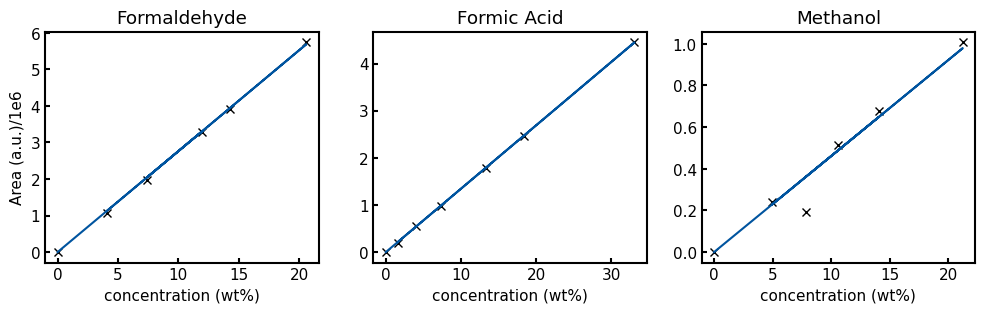

In [102]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize = (12, 3), ncols = 3)                                   # Create plot
for dictionary, ax in zip(dictionaries, [ax1, ax2, ax3]):                                           # loop through dictionaries
    ax.plot(dictionary['concentrations'], dictionary['areas']/1e6, 'kx')                            # plot data
    ax.plot(dictionary['concentrations'], dictionary['slope']*dictionary['concentrations']/1e6)     # plot fit
    ax.set_title(dictionary['name'])                                                                # set titles
    ax.set_xlabel('concentration (wt%)')                                                            # set xlabels
ax1.set_ylabel('Area (a.u.)/1e6')                                                                   # set ylabel
plt.show()

Define Functions for EMG

In [103]:
#Exponentially modified gaussian --> Tailing
def EMG(x, h, mu, sigma, tau):
    prefactor = (h* 0.5*tau)
    exp_arg = (0.5*tau *(2*mu+tau*sigma**2-2*x))
    erfc_arg = (mu+tau*sigma**2-x)/(np.sqrt(2)*sigma)
    return prefactor * np.exp(exp_arg) * erfc(erfc_arg)

#Mirrored Exponentially modified gaussian --> Fronting
def EMG_mirrored(x, h, mu, sigma, tau):
    return EMG(-x,h,-mu,sigma,tau)

#EMG + mirrored EMG
def EMGsTailFront(x, h1, mu1, sigma1, tau1, h2, mu2, sigma2, tau2):
    Tail_EMG = EMG(x, h1, mu1, sigma1, tau1)
    Front_EMG = EMG_mirrored(x, h2, mu2, sigma2, tau2)
    return Tail_EMG+Front_EMG

def gaussian(x, h, mu, sigma):
    # Normalized Gaussian: integral over all x is h
    return h * (1/(np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

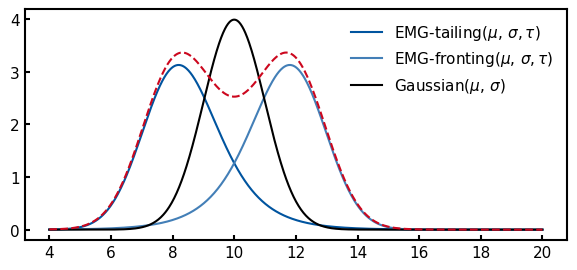

In [104]:
x = np.linspace(4, 20, 1000)  # Define x range for plotting
plt.plot(x, EMG(x, 10, 7.5, 1, 1), color='C0', label = r'EMG-tailing($\mu, \,\sigma,\tau$)')
plt.plot(x, EMG_mirrored(x, 10, 12.5, 1, 1), color='C1', label = r'EMG-fronting($\mu, \,\sigma,\tau$)')
plt.plot(x, gaussian(x, 10, 10, 1), color='k', label = r'Gaussian($\mu, \,\sigma$)')
plt.plot(x, EMGsTailFront(x, 10, 7.5, 1, 1, 10, 12.5, 1, 1), color='C4', linestyle='--')
plt.legend()
plt.show()

Define Chromatogram Extraction Function

In [105]:
def extract_chromatogram(filepath):                                         # definiere funktion
    with open(filepath, 'r', encoding='latin1') as f:                       # öffne file as f im lesemode
        lines = f.readlines()                                               # lies die zeilen

    for i, line in enumerate(lines):
        if line.strip().startswith('[LC Chromatogram(Detector B-Ch1)]'):    # sucht start des chromatogramms
            data_start = i + 8                                              # Skip 8 header lines
            break                                                           # brich loop ab, start gefunden

    data_lines = [] 
    for line in lines[data_start:]:                                         # fang beim start neuen loop an
        if not line.strip() or line.strip().startswith('['):                # abbrechen, wenn leere zeile
            break
        data_lines.append(line)                                             # sonst, zeile an data lines anhängen

    data = np.genfromtxt(data_lines, usecols=(0,1))                         # extract data
    data_export = np.column_stack([60*data[:,0], data[:,1]])                # time --> s 
    return data_export                                                      # return the data for chromatogram

(0.0, 1000.0002)

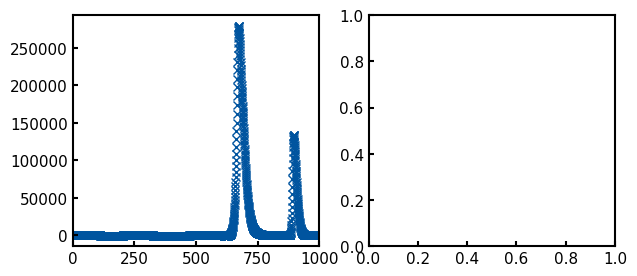

In [106]:
path_1 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/MF/' #35°C
file_1 = ['FKE-CAL-MF-HPLC-1.txt', 'FKE-CAL-MF-HPLC-2.txt', 'FKE-CAL-MF-HPLC-3.txt', 'FKE-CAL-MF-HPLC-4.txt', 'FKE-CAL-MF-HPLC-5.txt', 'FKE-CAL-MF-HPLC-6.txt', 'FKE-CAL-MF-HPLC-7.txt']

sample = extract_chromatogram(path_1+file_1[-1])    
index_1, index_2 = 0, 2000     

fig, (ax1, ax2) = plt.subplots(ncols=2)                                                                                         # Create Figure
ax1.plot(sample[index_1:index_2,0], sample[index_1:index_2,1], 'C0x')                                                           # Plot data
ax1.set_xlim(sample[index_1,0], sample[index_2,0])     

optimized parameters h, mu, sigma, tau: [3.19119746e+06 6.40861951e+02 3.37915339e+00 3.03835105e-01]
--------------------------------
Area from data: 3208919.3
Area from fit: 3191197.46
Concentration from data: 11.63 wt%
Concentration from fit: 11.56 wt%
Peak maximum 643.0 s
--------------------------------
FAld_tau (m,b) = [-1.69266500e-08  3.64125338e-01]
R² = 0.9860
FAld_sigma (m,b) = [-3.56837341e-08  3.50257835e+00]
R² = 0.9737
--------------------------------


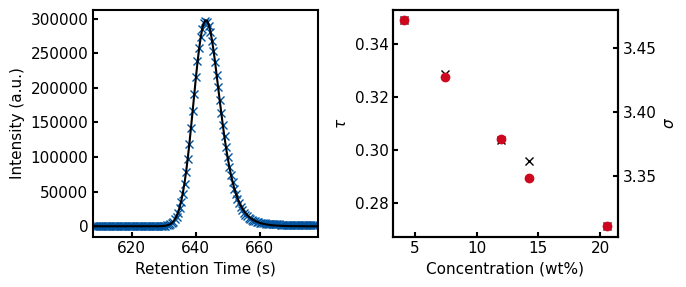

In [107]:
# Sigma and Tau determination for Formaldehyde
path_1 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/Formaldehyde/' #35°C
file_1 = ['FKE-Cal-FAld-1.txt', 'FKE-Cal-FAld-2.txt', 'FKE-Cal-FAld-3.txt', 'FKE-Cal-FAld-4.txt', 'FKE-Cal-FAld-5.txt']

sample = extract_chromatogram(path_1+file_1[0])                                                                                 # Extract Chromatogram
index_1, index_2 = np.argmax(sample[:,1])-70, np.argmax(sample[:,1])+70                                                         # Define start and end indices

initial_guess = [5e5, 642, 5,0.2]                                                                                               # Define initial guesses
popt, _ = sc.optimize.curve_fit(EMG, sample[:,0], sample[:,1], p0 = initial_guess)                                              # Optimize

print(f'optimized parameters h, mu, sigma, tau: {popt}')                                                                        # Print popt
print('-'*32)
h, mu, sigma, tau = popt                                                                                                        # Extract popt
EMG_1 = EMG(sample[index_1:index_2,0], h, mu, sigma, tau)                                                                       # Generate fitfunction

#calculate area from data, print results
A = trapezoid(sample[index_1:index_2,1], sample[index_1:index_2,0], axis=0)                                                     # Area from Data
print(f'Area from data: {round(A,2)}')                                                                                          # Print Area from Data 
print(f'Area from fit: {round(h,2)}')                                                                                           # Print Area from Fit
print(f'Concentration from data: {round(A/FAld['slope'],2)} wt%')                                                               # Print Concentration from Data
print(f'Concentration from fit: {round(h/FAld['slope'],2)} wt%')                                                                # Print Concentration from Fit 
print(f'Peak maximum {round(sample[index_1:index_2,0][np.argmax(EMG_1)],2)} s')                                                 # Print Peak Maxima
print('-'*32)

fig, (ax1, ax2) = plt.subplots(ncols=2)                                                                                         # Create Figure
ax1.plot(sample[index_1:index_2,0], sample[index_1:index_2,1], 'C0x')                                                           # Plot data
ax1.plot(sample[index_1:index_2,0], EMG_1, color = 'k')                                                                         # Plot Fit
ax1.set_xlim(sample[index_1,0], sample[index_2,0])                                                                              # Set xlim

FAld_area_arr = FAld['concentrations'][1:]*FAld['slope']                                                                        # Calculate Areas
#tau
FAld_tau_arr=np.array([0.3038,0.3286,0.2958,0.2713,0.3489])                                                                     # Hardcoded simulated taus
FAld_coeffs_tau = np.polyfit(FAld_area_arr, (FAld_tau_arr), 1)                                                                  # Linear fit for tau
print(f'FAld_tau (m,b) = {FAld_coeffs_tau}')                                                                                    # print fit coefficients
R_sq(np.poly1d(FAld_coeffs_tau), FAld_area_arr, (FAld_tau_arr))                                                                 # print R^2
#sigma
FAld_width_arr=np.array([3.379,3.428,3.349,3.311,3.472])                                                                        # Hardcoded simulated sigmas
FAld_coeffs_wid = np.polyfit(FAld_area_arr, (FAld_width_arr), 1)                                                                # Linear fit for sigma
print(f'FAld_sigma (m,b) = {FAld_coeffs_wid}')                                                                                  # print fit coefficients
R_sq(np.poly1d(FAld_coeffs_wid), FAld_area_arr, (FAld_width_arr))                                                               # print R^2
print('-'*32)

ax2.plot(FAld_area_arr/FAld['slope'], (FAld_tau_arr), 'kx')
ax2_2 = ax2.twinx()
ax2_2.plot(FAld_area_arr/FAld['slope'], (FAld_width_arr), 'C4o')
ax1.set_xlabel('Retention Time (s)')
ax1.set_ylabel('Intensity (a.u.)')
ax2.set_xlabel('Concentration (wt%)')
ax2.set_ylabel(r'$\tau$')
ax2_2.set_ylabel(r'$\sigma$')
fig.tight_layout()
plt.show()


C:\Users\FKetter.ITMC\AppData\Local\Temp\ipykernel_10000\1507433911.py:6: RuntimeWarning: overflow encountered in exp
  return prefactor * np.exp(exp_arg) * erfc(erfc_arg)
C:\Users\FKetter.ITMC\AppData\Local\Temp\ipykernel_10000\1507433911.py:6: RuntimeWarning: overflow encountered in multiply
  return prefactor * np.exp(exp_arg) * erfc(erfc_arg)
C:\Users\FKetter.ITMC\AppData\Local\Temp\ipykernel_10000\1507433911.py:6: RuntimeWarning: invalid value encountered in multiply
  return prefactor * np.exp(exp_arg) * erfc(erfc_arg)


optimized parameters h, mu, sigma, tau: [2.45144895e+06 6.68919152e+02 2.76408334e+00 1.93827874e-01]
--------------------------------
Area from data: 2470296.99
Area from fit: 2451448.95
Concentration from data: 18.37 wt%
Concentration from fit: 18.23 wt%
Peak maximum 666.0 s
--------------------------------
FA_tau (m,b) = [3.52016811e-08 1.14324405e-01]
R² = 0.9876
FA_sigma (m,b) = [2.67559639e-07 2.15677035e+00]
R² = 0.9781
--------------------------------


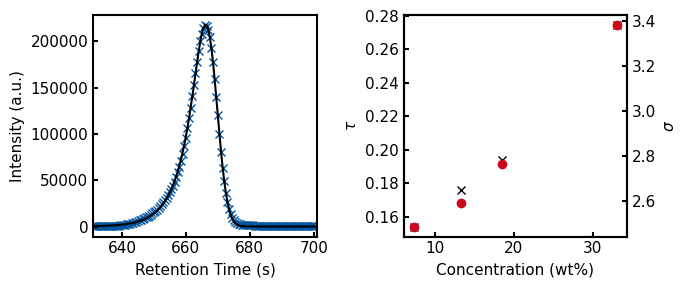

In [108]:
# Sigma and Tau determination for Formic Acid
path_1 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FormicAcid/' # 35°C
file_1 = ['FKE-Cal-FA-2-1.txt', 'FKE-Cal-FA-2-2.txt', 'FKE-Cal-FA-2-3.txt', 'FKE-Cal-FA-2-4.txt', 'FKE-Cal-FA-2-5.txt', 'FKE-Cal-FA-2-6.txt']

sample = extract_chromatogram(path_1 + file_1[2])                                                                                # Extract Chromatogram
index_1, index_2 = np.argmax(sample[:,1])-70, np.argmax(sample[:,1])+70                                                          # Define start and end indices

initial_guess = [5e5, 642, 5, 0.2]                                                                                               # Define initial guesses
popt, _ = sc.optimize.curve_fit(EMG_mirrored, sample[:,0], sample[:,1], p0 = initial_guess)                                      # Optimize

print(f'optimized parameters h, mu, sigma, tau: {popt}')                                                                         # Print popt
print('-'*32)
h, mu, sigma, tau = popt                                                                                                         # Extract popt
EMG_1 = EMG_mirrored(sample[index_1:index_2,0], h, mu, sigma, tau)                                                               # Generate fitfunction

# calculate area from data, print results
A = trapezoid(sample[index_1:index_2,1], sample[index_1:index_2,0], axis=0)                                                      # Area from Data
print(f'Area from data: {round(A,2)}')                                                                                           # Print Area from Data 
print(f'Area from fit: {round(h,2)}')                                                                                            # Print Area from Fit
print(f'Concentration from data: {round(A/FA["slope"],2)} wt%')                                                                  # Print Concentration from Data
print(f'Concentration from fit: {round(h/FA["slope"],2)} wt%')                                                                   # Print Concentration from Fit 
print(f'Peak maximum {round(sample[index_1:index_2,0][np.argmax(EMG_1)],2)} s')                                                  # Print Peak Maxima
print('-'*32)

fig, (ax1, ax2) = plt.subplots(ncols=2)                                                                                          # Create Figure
ax1.plot(sample[index_1:index_2,0], sample[index_1:index_2,1], 'C0x')                                                            # Plot data
ax1.plot(sample[index_1:index_2,0], EMG_1, color='k')                                                                            # Plot Fit
ax1.set_xlim(sample[index_1,0], sample[index_2,0])                                                                               # Set xlim

FA_area_arr = np.array([7.30, 18.44, 33.10, 13.29]) * FA['slope']                                                                # Calculate Areas
FA_tau_arr = np.array([0.1541, 0.1938, 0.2746, 0.1762])                                                                          # Hardcoded simulated taus
FA_coeffs_tau = np.polyfit(FA_area_arr, FA_tau_arr, 1)                                                                           # Linear fit for tau
print(f'FA_tau (m,b) = {FA_coeffs_tau}')                                                                                         # print fit coefficients
R_sq(np.poly1d(FA_coeffs_tau), FA_area_arr, FA_tau_arr)                                                                          # print R^2

FA_width_arr = np.array([2.485, 2.764, 3.382, 2.591])                                                                            # Hardcoded simulated sigmas
FA_coeffs_wid = np.polyfit(FA_area_arr, FA_width_arr, 1)                                                                         # Linear fit for sigma
print(f'FA_sigma (m,b) = {FA_coeffs_wid}')                                                                                       # print fit coefficients
R_sq(np.poly1d(FA_coeffs_wid), FA_area_arr, FA_width_arr)                                                                        # print R^2
print('-'*32)

ax2.plot(FA_area_arr/FA['slope'], FA_tau_arr, 'kx')                                                                              # tau-Plot
ax2_2 = ax2.twinx()
ax2_2.plot(FA_area_arr/FA['slope'], FA_width_arr, 'C4o')                                                                         # sigma-Plot
ax1.set_xlabel('Retention Time (s)')
ax1.set_ylabel('Intensity (a.u.)')
ax2.set_xlabel('Concentration (wt%)')
ax2.set_ylabel(r'$\tau$')
ax2_2.set_ylabel(r'$\sigma$')
fig.tight_layout()
plt.show()

In [109]:
#Tests with preset FAld and FA concentration
FAld_conc, FA_conc = 5.64, 9.53                                                     # wt% of base concentrations
Names = np.array(['FAFAld1', 'FAFAld2', 'FAFAld3', 'FAFAld4'])                      # Names of the mixtures
FAld_mass = np.array([0.4588, 0.9178, 0.6543, 0.5735])                              # masses FAld
FA_mass = np.array([0.6864, 0.3066, 0.5077, 0.9715])                                # masses FA
wt_perc_FAld = FAld_conc*FAld_mass/(FAld_mass+FA_mass)                              # calculation of wt%
wt_perc_FA = FA_conc*FA_mass/(FAld_mass+FA_mass)

print('Concentrations measured at 40°C and 35°C on 23.05 bzw. 27.05, here 35°C')    # print table 1 
print(f"{'Name':<10} {'wt% FAld':>10} {'wt% FA':>10}")
print("-" * 32)
for name, wtFAld, wtFA in zip(Names, wt_perc_FAld, wt_perc_FA):
    print(f"{name:<10} {wtFAld:10.2f} {wtFA:10.2f}")
#----------------------------------------------------------------------------#
Names = np.array(['FA1', 'FA2', 'FAld1', 'FAld2', 'FAFAld1', 'FAFAld2'])            # do the same for the second data set
FAld_mass = np.array([0,0,0.8537,0.2946,0.4492,0.2454])
FA_mass = np.array([0.6311,0.7365,0,0,0.5593,0.3887])
Water_mass = np.array([0.7587,0.4399,0.5144,0.8567,0.4244,0.6128])
wt_perc_FAld = FAld_conc*FAld_mass/(FAld_mass+FA_mass+Water_mass)
wt_perc_FA = FA_conc*FA_mass/(FAld_mass+FA_mass+Water_mass)

print()
print('Concentrations measured at 35 °C on 27.05')
print(f"{'Name':<10} {'wt% FAld':>10} {'wt% FA':>10}")
print("-" * 32)
for name, wtFAld, wtFA in zip(Names, wt_perc_FAld, wt_perc_FA):
    print(f"{name:<10} {wtFAld:10.2f} {wtFA:10.2f}")

Concentrations measured at 40°C and 35°C on 23.05 bzw. 27.05, here 35°C
Name         wt% FAld     wt% FA
--------------------------------
FAFAld1          2.26       5.71
FAFAld2          4.23       2.39
FAFAld3          3.18       4.16
FAFAld4          2.09       5.99

Concentrations measured at 35 °C on 27.05
Name         wt% FAld     wt% FA
--------------------------------
FA1              0.00       4.33
FA2              0.00       5.97
FAld1            3.52       0.00
FAld2            1.44       0.00
FAFAld1          1.77       3.72
FAFAld2          1.11       2.97


1218 1358


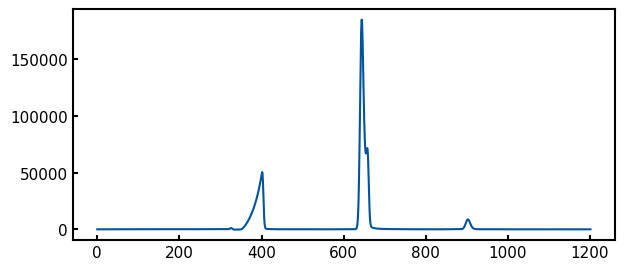

In [110]:
path_1 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld/'
files_1 = ['FKE-CAL-FALD-FA-HPLC-1.txt', 'FKE-CAL-FALD-FA-HPLC-2.txt', 'FKE-CAL-FALD-FA-HPLC-3.txt', 'FKE-CAL-FALD-FA-HPLC-4.txt']

path_2 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld_2/'
files_2 = ['FKE-Test-FA-1.txt', 'FKE-Test-FA-2.txt', 'FKE-Test-FALD-1.txt', 'FKE-Test-FALD-2.txt', 'FKE-Test-FAFALD-1.txt', 'FKE-Test-FAFALD-2.txt']

path_e = '../01_unprocessed_data/HPLC/Electrolytes/'
path_s = '../01_unprocessed_data/HPLC/Educts/'
path_r = '../01_unprocessed_data/HPLC/Reactions/'
files_s = ['FKE-SOL-007-HPLC-2.txt', 'FKE-SOL-008-HPLC-1.txt', 'FKE-SOL-008-2-HPLC-1.txt', 'FKE-SOL-008-3-HPLC-1.txt', 'FKE-SOL-009-HPLC-1.txt', 'FKE-SOL-008-4-HPLC-1']
files_r = ['FKE-EXP-015-HPLC-1.txt', 'FKE-EXP-016-HPLC-1.txt', 'FKE-EXP-017-HPLC-1.txt', 'FKE-EXP-018-HPLC-2.txt', 'FKE-EXP-019-HPLC-1.txt', 'FKE-EXP-020-HPLC-1.txt',
            'FKE-EXP-021-HPLC-1.txt', 'FKE-EXP-022-HPLC-1.txt','FKE-EXP-023-HPLC-1.txt', 'FKE-EXP-024-HPLC-1.txt','FKE-EXP-025-HPLC-1.txt', 'FKE-EXP-026-HPLC-1.txt']
file = 'FKE-EXP-022-HPLC-1'
sample = extract_chromatogram(path_r+file+'.txt')
sample_name = file

mask = (sample[:, 0] >= 500) & (sample[:, 0] <= 750)
masked_indices = np.where(mask)[0]
index_1 = masked_indices[np.argmax(sample[mask, 1])]-70
index_2 = index_1 + 140
print(index_1, index_2)
plt.plot(sample[:,0], sample[:,1])
plt.show()

In [111]:
beta = 10.91/100
rho = 1.073
mole_per_l = 1000*beta*rho/30.03

print(mole_per_l)

print(22.5/3.4)
print(51.62*0.5)
print(6.62*3.9)

3.8982450882450883
6.61764705882353
25.81
25.818


Unconstrained fit
--------------------------------------------------------------------------------
FKE-EXP-022-HPLC-1
--------------------------------------------------------------------------------
Peak       h            mu         sigma      tau        [wt%]        Peak pos.   
--------------------------------------------------------------------------------
FAld       2184575.84   641.159    3.327      0.216      7.91         644.00      
FA         487869.11    660.306    2.342      0.275      3.63         658.00      
MeOH       ----------------------------------------      2.75         902.50      


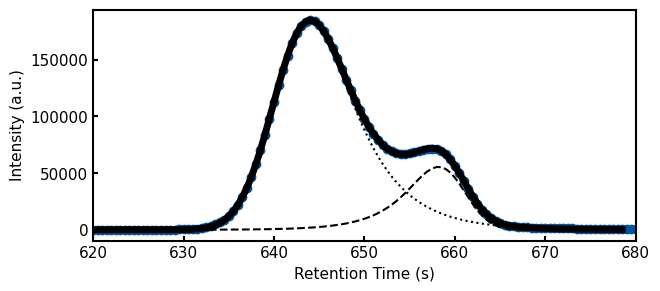

In [112]:
#Unconstrained fit
print('Unconstrained fit')
print('-'*80)
print(sample_name)
print('-'*80)

initial_guess = [1e5, 644, 3.625, 0.33, 1e4, 660, 2.665, 0.1634]                        
lower_bounds = [0, 640, 0, 0, 0, 658, 0, 0]
upper_bounds = [np.inf, 645, 4, 0.7, np.inf, 666, 3, 0.3]
popt, _ = sc.optimize.curve_fit(EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])
h1, mu1, sigma1, tau1 = popt[:4]
h2, mu2, sigma2, tau2 = popt[4:]

#calculate fit functions
EMG_FAld = EMG(sample[index_1:index_2,0], h1, mu1, sigma1, tau1)
EMG_FA   = EMG_mirrored(sample[index_1:index_2,0], h2, mu2, sigma2, tau2)

#Methanol:
mask = (sample[:,0] > 850) & (sample[:,0] < 950)
index_3, index_4 = np.argmax(sample[:, 1][mask])-70, np.argmax(sample[:, 1][mask])+70
index_3_full, index_4_full = np.where(mask)[0][index_3], np.where(mask)[0][index_4]
integral_MeOH = trapezoid(sample[index_3_full:index_4_full,1], sample[index_3_full:index_4_full,0], axis=0)
concentration_MeOH = integral_MeOH/MeOH['slope']
peak_time = sample[mask][np.argmax(sample[mask][:,1]),0]

# Table for popt parameters, concentration and peak position
print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")
print("-" * 80)
print(f"{'FAld':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FAld['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")
print(f"{'MeOH':<10} {'-'*40} {' '*4} {concentration_MeOH:<12.2f} {peak_time:<12.2f}")

#plot 
fig, ax = plt.subplots()
ax.plot(sample[:,0], sample[:,1], 'C0o')
ax.plot(sample[index_1:index_2,0], EMG_FAld, 'k:')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--')
ax.plot(sample[index_1:index_2,0], EMG_FAld+EMG_FA, 'k-', lw = 5)

ax.set_xlim(620, 680)
#ax.set_ylim(0, 120000)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
plt.show()

In [113]:
def constrained_EMG(x, h, mu, tau):
    sigma = FAld_coeffs_wid[1]+h*FAld_coeffs_wid[0]

    if sigma <= 0 or tau <= 0:
        return np.full_like(x, np.nan)

    prefactor = (h* 0.5*tau)
    exp_arg = (0.5*tau *(2*mu+tau*sigma**2-2*x))
    erfc_arg = (mu+tau*sigma**2-x)/(np.sqrt(2)*sigma)
    return prefactor * np.exp(exp_arg) * erfc(erfc_arg)

def constrained_EMG_mirrored(x, h, mu, tau):
    sigma = FA_coeffs_wid[1]+h*FA_coeffs_wid[0]
    
    if sigma <= 0 or tau <= 0:
        return np.full_like(x, np.nan)

    return EMG(-x,h,-mu,sigma,tau)

'''Exponentially Modified Gaussian + Mirrored EMG'''
def constrained_EMGsTailFront(x, h1, mu1, tau1, h2, mu2, tau2):
    Tail_EMG = constrained_EMG(x, h1, mu1, tau1)
    Front_EMG = constrained_EMG_mirrored(x, h2, mu2, tau2)
    return Tail_EMG+Front_EMG

Constrained fit - only sigma
--------------------------------------------------------------------------------
FKE-EXP-022-HPLC-1
--------------------------------------------------------------------------------
Peak       h            mu         sigma      tau        [wt%]        Peak pos.   
--------------------------------------------------------------------------------
FAld       2110934.76   641.326    3.427      0.243      7.65         644.00      
FA         559168.54    660.478    2.306      0.227      4.16         658.00      
MeOH       ----------------------------------------      2.75         902.50      


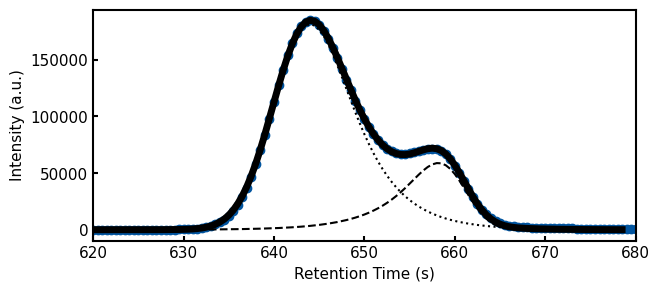

In [114]:
#import chromatogram
print('Constrained fit - only sigma')
print('-'*80)
print(sample_name)
print('-'*80)

#fit values and print optimized parameters
initial_guess = [8e5, 644, 0.35, 1e4, 660, 0.13]
lower_bounds = [0, 640, 0, 0, 660, 0]
upper_bounds = [np.inf, 650, 0.5, np.inf, 666, 0.5]

popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])
h1, mu1, tau1 = popt[:3]
sigma1 = FAld_coeffs_wid[1]+h1*FAld_coeffs_wid[0]
h2, mu2, tau2 = popt[3:]
sigma2 = FA_coeffs_wid[1]+h2*FA_coeffs_wid[0]

#calculate fit functions
EMG_FAld = constrained_EMG(sample[index_1:index_2,0], h1, mu1, tau1)
EMG_FA   = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2, tau2)

#Methanol:
mask = (sample[:,0] > 850) & (sample[:,0] < 950)
index_3, index_4 = np.argmax(sample[:, 1][mask])-70, np.argmax(sample[:, 1][mask])+70
index_3_full, index_4_full = np.where(mask)[0][index_3], np.where(mask)[0][index_4]
integral_MeOH = trapezoid(sample[index_3_full:index_4_full,1], sample[index_3_full:index_4_full,0], axis=0)
concentration_MeOH = integral_MeOH/MeOH['slope']
peak_time = sample[mask][np.argmax(sample[mask][:,1]),0]

# Table for popt parameters, concentration and peak position (alles linksbündig)
print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")
print("-" * 80)
print(f"{'FAld':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FAld['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")
print(f"{'MeOH':<10} {'-'*40} {' '*4} {concentration_MeOH:<12.2f} {peak_time:<12.2f}")

#plot 
fig, ax = plt.subplots()
ax.plot(sample[:,0], sample[:,1], 'C0o')
ax.plot(sample[index_1:index_2,0], EMG_FAld, 'k:')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--')
ax.plot(sample[index_1:index_2,0], EMG_FAld+EMG_FA, 'k-', lw = 5)

ax.set_xlim(620,680)
#ax.set_ylim(-100000, 120000)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
plt.show()

In [115]:
M_FAld = 30
M_CH4O2 = 48
M_FA = 46
M_MeOH = 32
f = M_CH4O2/M_FAld
V = 100

SOL_008_2 = {
    'c0_FAld':14.74,
    'c0_MeOH': 1.11,
    'c0_FA': 0}
SOL_008_3 = {
    'c0_FAld':14.09,
    'c0_MeOH': 0.8,
    'c0_FA': 0}
SOL_008_4 = {
    'c0_FAld':15.33,
    'c0_MeOH': 0.8,
    'c0_FA': 0}

w0_CH4O2, w0_MeOH, w0_FA = SOL_008_4['c0_FAld']*V/(V+10)*f, SOL_008_4['c0_MeOH']*V/(V+10), SOL_008_4['c0_FA']                  
w1_CH4O2, w1_MeOH, w1_FA = h1/FAld['slope']*f, concentration_MeOH, h2/FA['slope']         
print(w1_CH4O2, w1_MeOH, w1_FA)

c_CH4O2 = (w0_CH4O2 - w1_CH4O2)/M_CH4O2 #used
c_FA = (w1_FA - w0_FA)/M_FA #produced
c_MeOH = (w1_MeOH-w0_MeOH)/M_MeOH #produced

H2_gen = 2*(c_CH4O2-c_FA-c_MeOH) + c_FA - c_MeOH
CO2_gen = (c_CH4O2-c_FA-c_MeOH)
print(f'CH4O2 >> CO2 + 2*H2: {c_CH4O2-c_FA-c_MeOH}')
print(f'CH4O2 >> H2 + FA: {c_FA}')
print(f'CH4O2 + H2 >> H2O + CH3OH: {c_MeOH}')
print(f'H2-to-CO2: {H2_gen/CO2_gen}')



12.236826220611198 2.7494319051844185 4.1586802200260555
CH4O2 >> CO2 + 2*H2: 0.0560130088999507
CH4O2 >> H2 + FA: 0.09040609173969685
CH4O2 + H2 >> H2O + CH3OH: 0.06319247430974034
H2-to-CO2: 2.4858445915405993


In [116]:
def constrained_EMG(x, h, mu):
    tau = FAld_coeffs_tau[1]+h*FAld_coeffs_tau[0]
    sigma = FAld_coeffs_wid[1]+h*FAld_coeffs_wid[0]

    if sigma <= 0 or tau <= 0:
        return np.full_like(x, np.nan)

    prefactor = (h* 0.5*tau)
    exp_arg = (0.5*tau *(2*mu+tau*sigma**2-2*x))
    erfc_arg = (mu+tau*sigma**2-x)/(np.sqrt(2)*sigma)
    return prefactor * np.exp(exp_arg) * erfc(erfc_arg)

def constrained_EMG_mirrored(x, h, mu):
    tau = FA_coeffs_tau[1]+h*FA_coeffs_tau[0]
    sigma = FA_coeffs_wid[1]+h*FA_coeffs_wid[0]

    if sigma <= 0 or tau <= 0:
        return np.full_like(x, np.nan)

    return EMG(-x,h,-mu,sigma,tau)

'''Exponentially Modified Gaussian + Mirrored EMG'''
def constrained_EMGsTailFront(x, h1, mu1, h2, mu2):
    Tail_EMG = constrained_EMG(x, h1, mu1)
    Front_EMG = constrained_EMG_mirrored(x, h2, mu2)
    return Tail_EMG+Front_EMG

Constrained fit
--------------------------------------------------------------------------------
Peak       h            mu         sigma      tau        [wt%]        Peak pos.   
--------------------------------------------------------------------------------
FAld       1856995.21   641.748    3.436      0.333      6.73         644.00      
FA         817147.36    660.704    2.375      0.143      6.08         658.00      
MeOH       ----------------------------------------      2.75         902.50      


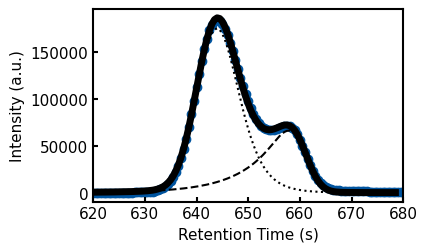

In [117]:
#import chromatogram
print('Constrained fit')
print('-'*80)
path_35 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld/'
files_35 = ['FKE-CAL-FALD-FA-HPLC-1.txt', 'FKE-CAL-FALD-FA-HPLC-2.txt', 'FKE-CAL-FALD-FA-HPLC-3.txt', 'FKE-CAL-FALD-FA-HPLC-4.txt']

path_35_2 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld_2/'
files_35_2 = ['FKE-Test-FA-1.txt', 'FKE-Test-FA-2.txt', 'FKE-Test-FALD-1.txt', 'FKE-Test-FALD-2.txt', 'FKE-Test-FAFALD-1.txt', 'FKE-Test-FAFALD-2.txt']


initial_guess = [1e7, 644, 1e5, 658]                                                                                    # define initial guesses and bounds
lower_bounds = [1, 630, 1, 656]
upper_bounds = [np.inf, 645, np.inf, 665]

popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],        # calculate popt
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])

h1, mu1 = popt[:2]                                                                                                      # calculate sigma and tau
sigma1 = FAld_coeffs_wid[1]+h1*FAld_coeffs_wid[0]
tau1 = FAld_coeffs_tau[1]+h1*FAld_coeffs_tau[0]
h2, mu2 = popt[2:]
sigma2 = FA_coeffs_wid[1]+h2*FA_coeffs_wid[0]
tau2 = FA_coeffs_tau[1]+h2*FA_coeffs_tau[0]

EMG_FAld = constrained_EMG(sample[index_1:index_2,0], h1, mu1)                                                          # calculate fit functions
EMG_FA   = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2)

#Methanol:
mask = (sample[:,0] > 850) & (sample[:,0] < 950)
index_3, index_4 = np.argmax(sample[:, 1][mask])-70, np.argmax(sample[:, 1][mask])+70
index_3_full, index_4_full = np.where(mask)[0][index_3], np.where(mask)[0][index_4]
integral_MeOH = trapezoid(sample[index_3_full:index_4_full,1], sample[index_3_full:index_4_full,0], axis=0)
concentration_MeOH = integral_MeOH/MeOH['slope']
peak_time = sample[mask][np.argmax(sample[mask][:,1]),0]

print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")                   #print Peak pos and popt
print("-" * 80)
print(f"{'FAld':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FAld['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")
print(f"{'MeOH':<10} {'-'*40} {' '*4} {concentration_MeOH:<12.2f} {peak_time:<12.2f}")

fig, ax = plt.subplots(figsize = (4,2.5))                                                                                #plot
ax.plot(sample[:,0], sample[:,1], 'C0o')
ax.plot(sample[index_1:index_2,0], EMG_FAld, 'k:')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--')
ax.plot(sample[index_1:index_2,0], EMG_FAld+EMG_FA, 'k-', lw = 5)
ax.set_xlim(620, 680)
#ax.set_ylim(0, 120000)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
plt.show()